# Multimodal models and Vision–Language Models (VLMs)

In this seminar we will look at three representative families of vision–language models, moving from the simplest design to the most modern one:

1. **CLIP** — a *contrastive dual-encoder*: separate image and text towers trained so that matching image–text pairs end up close in a shared embedding space. We will use it to inspect what the model "looks at" (token-level relevance) and to do zero-shot semantic search.
2. **BLIP-2** — a *non-tokenized early-fusion* VLM: a frozen image encoder is connected to a frozen LLM through a small learnable bridge (the **Q-Former**). This is the architecture behind most modern open VLMs.
3. **Qwen-VL** — a fully *generative* chat-style VLM where vision tokens are fed directly into a chat-tuned LLM, enabling multi-turn visual question answering and grounding.

Throughout the notebook the cells marked with `# YOUR CODE` are tasks for you to complete.

**References**

* Yin et al., [*The Evolution of Multimodal Model Architectures*](https://arxiv.org/pdf/2405.17927) — taxonomy of VLM designs (we will follow categories A–D from this paper).
* Hugging Face, [*Multimodal Text and Vision Models*](https://huggingface.co/learn/computer-vision-course/en/unit4/multimodal-models/pre-intro) — a more applied tutorial.

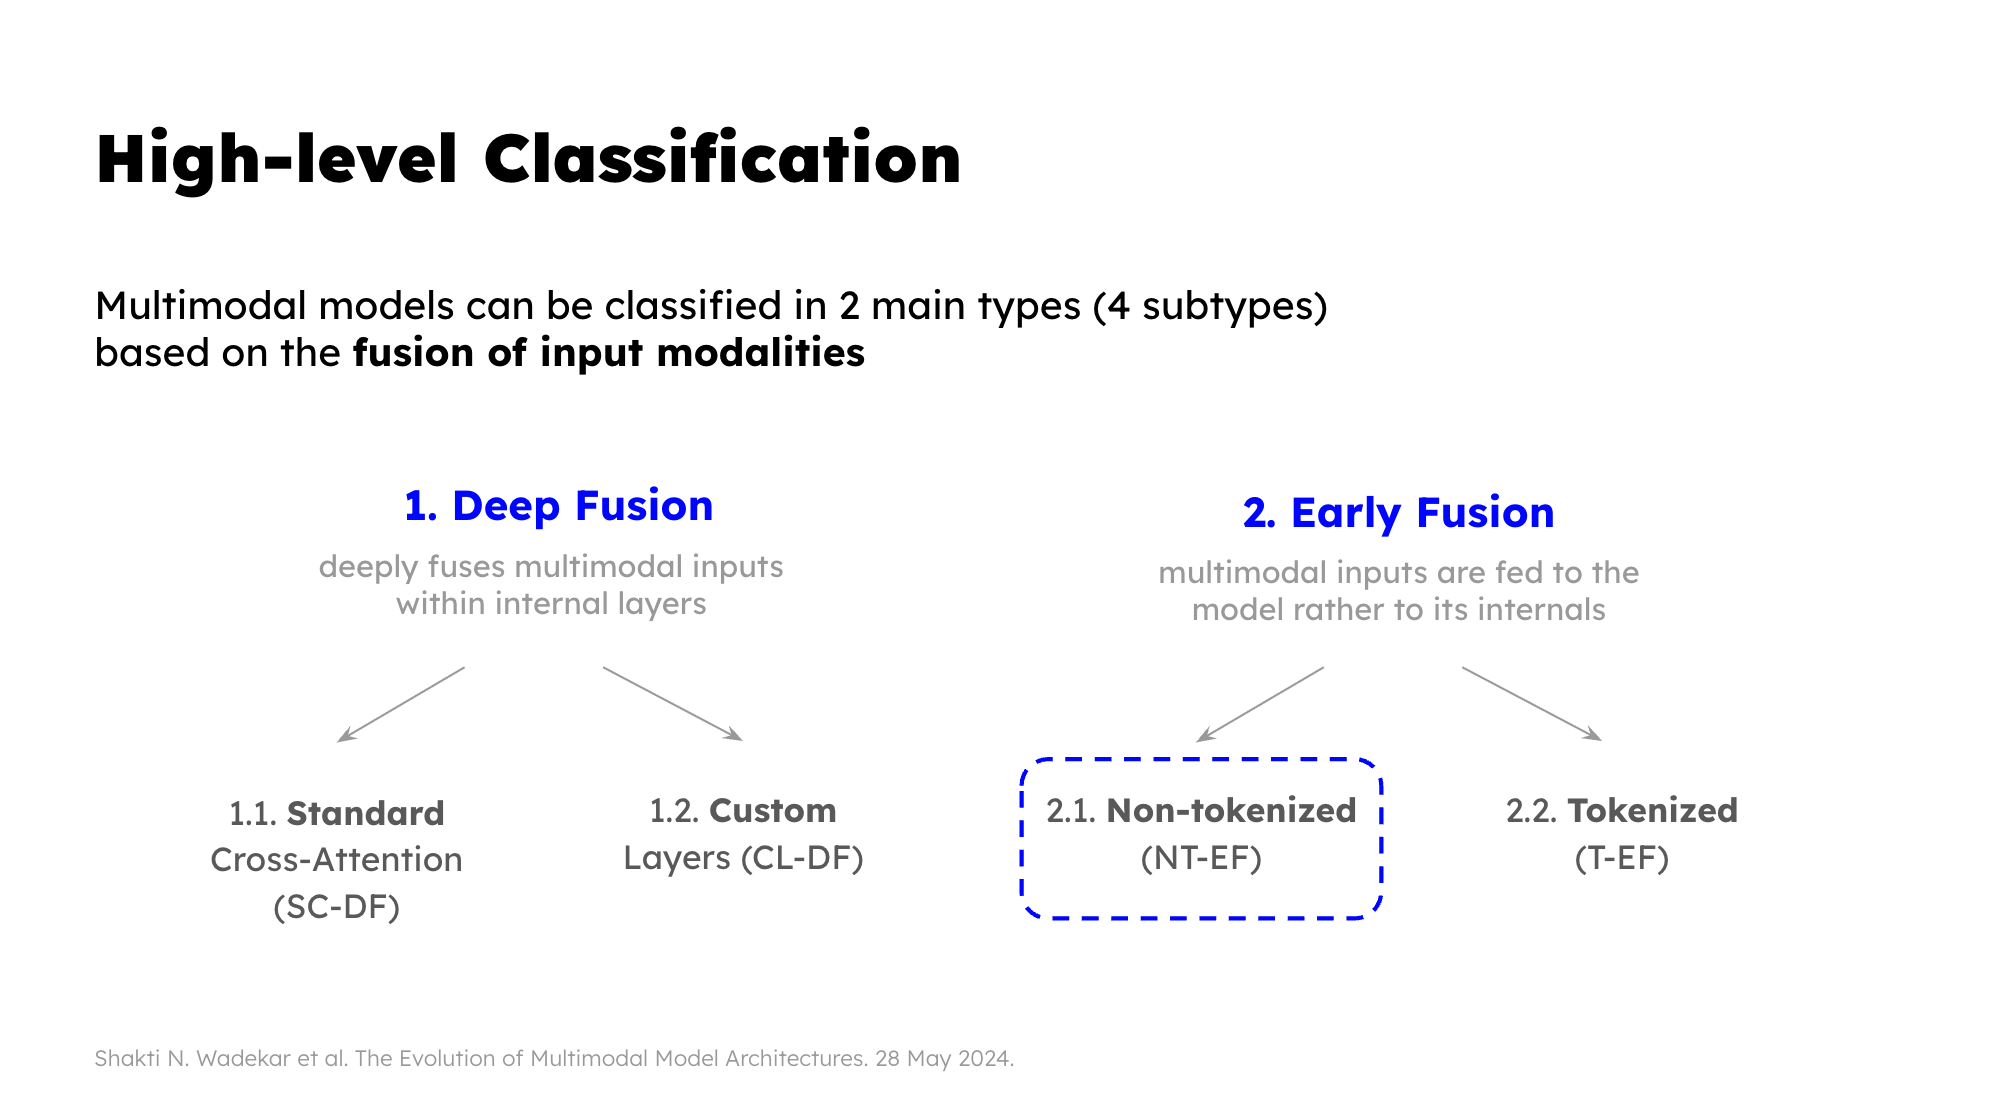

## 1. CLIP — Contrastive Language–Image Pre-training

CLIP (Radford et al., 2021) jointly trains an image encoder $f_v$ and a text encoder $f_t$ on 400M image–caption pairs scraped from the web. The two encoders project their inputs into a shared $d$-dimensional embedding space, and the model is optimized so that real (image, caption) pairs are close while mismatched pairs are far apart in this space.

**Useful reading:**

* [CLIP (Contrastive Language–Image Pre-training)](https://openai.com/blog/clip/) — original blog post.
* Radford et al., [*Learning Transferable Visual Models From Natural Language Supervision*](https://arxiv.org/abs/2103.00020) — the paper.
* Lilian Weng, [*Contrastive Representation Learning*](https://lilianweng.github.io/posts/2021-05-31-contrastive/#clip) — a great survey, with the CLIP section in particular.

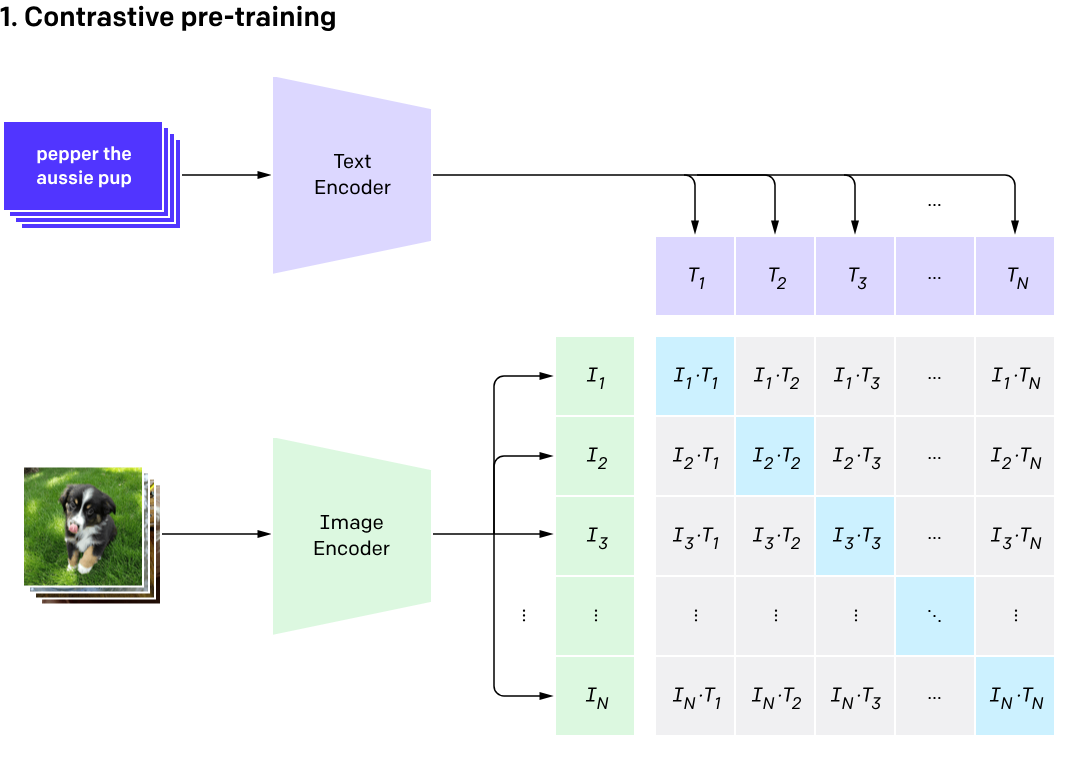

Given a batch of $N$ (image, text) pairs, CLIP computes the dense $N \times N$ cosine-similarity matrix between every image and every caption in the batch. Training maximizes the similarity of the $N$ matching pairs (the diagonal — blue cells in the figure) and minimizes the similarity of all $N^2 - N$ off-diagonal pairs (grey cells). Concretely, the loss is the symmetric InfoNCE / cross-entropy:

$$
\mathcal{L} = \tfrac{1}{2}\bigl(\mathrm{CE}(\text{logits}_{i\to t}, y) + \mathrm{CE}(\text{logits}_{t\to i}, y)\bigr),
\qquad \text{logits} = \tau \cdot f_v(\mathbf{I}) \, f_t(\mathbf{T})^{\top},
$$

where $\tau$ is a learned temperature and $y = (0, 1, \dots, N-1)$ are the indices of the matching pairs.

The resulting joint embedding is remarkably useful. Typical applications include:

* **Zero-shot image classification** — embed class names as captions and pick the closest one;
* **Cross-modal similarity / semantic search** — find images by a textual query (or vice versa);
* **Conditioning generative models** — e.g. CLIP-guided text-to-image generation, classifier-free guidance, retrieval-augmented generation.

### 1.1 CLIP Attention — what does the model actually look at?

A natural question is: *which* image regions and *which* tokens drive a given image–text similarity? Raw attention weights are a poor explanation on their own, so we use the **gradient × attention** rollout proposed in [Chefer et al., *Generic Attention-Model Explainability*](https://arxiv.org/abs/2103.15679) (CVPR 2021), reusing the authors' [reference implementation](https://github.com/hila-chefer/Transformer-MM-Explainability).

Intuitively, for each Transformer block we compute

$$
R \leftarrow R + \overline{\bigl(\nabla A \odot A\bigr)^{+}} \cdot R,
$$

where $A$ is the attention map of the block, $\nabla A$ is its gradient w.r.t. the target similarity score, $(\cdot)^{+}$ keeps only positive contributions and the bar denotes head averaging. The relevance map $R$ is then projected onto image patches (and, separately, text tokens).

In [ ]:
import os

# Clone the reference implementation only if it is not already present (safe to re-run).
if not os.path.isdir("Transformer-MM-Explainability"):
    !git clone https://github.com/hila-chefer/Transformer-MM-Explainability

# Switch into the repo so that `import CLIP.clip as clip` resolves to its local fork.
if os.path.basename(os.getcwd()) != "Transformer-MM-Explainability":
    os.chdir("Transformer-MM-Explainability")

!pip install -q einops ftfy captum

In [ ]:
import torch
import CLIP.clip as clip
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from captum.attr import visualization

In [ ]:
# From which Transformer block to start the relevance rollout.
# `-1` means "use only the last block" (the cheapest setting, default in the paper).
# Setting it to a smaller index aggregates relevance across more blocks.
start_layer = -1
start_layer_text = -1

In [ ]:
def interpret(image, texts, model, device, start_layer=start_layer, start_layer_text=start_layer_text):
    """Compute Chefer et al.'s gradient-attention relevance for both modalities.

    For each text candidate in `texts` we backpropagate from its image–text
    similarity score, multiply the attention maps by their gradients, and roll
    the resulting per-block contributions into a final relevance matrix R.

    Returns:
        text_relevance: (batch, seq_len, seq_len) — relevance over text tokens
        image_relevance: (batch, num_patches) — relevance over image patches
    """
    batch_size = texts.shape[0]
    images = image.repeat(batch_size, 1, 1, 1)
    logits_per_image, logits_per_text = model(images, texts)
    probs = logits_per_image.softmax(dim=-1).detach().cpu().numpy()
    index = [i for i in range(batch_size)]

    one_hot = np.zeros((logits_per_image.shape[0], logits_per_image.shape[1]), dtype=np.float32)
    one_hot[torch.arange(logits_per_image.shape[0]), index] = 1
    one_hot = torch.from_numpy(one_hot).requires_grad_(True)
    one_hot = torch.sum(one_hot.cuda() * logits_per_image)
    model.zero_grad()

    image_attn_blocks = list(dict(model.visual.transformer.resblocks.named_children()).values())

    if start_layer == -1:
      # calculate index of last layer
      start_layer = len(image_attn_blocks) - 1

    num_tokens = image_attn_blocks[0].attn_probs.shape[-1]
    R = torch.eye(num_tokens, num_tokens, dtype=image_attn_blocks[0].attn_probs.dtype).to(device)
    R = R.unsqueeze(0).expand(batch_size, num_tokens, num_tokens)
    for i, blk in enumerate(image_attn_blocks):
        if i < start_layer:
          continue
        grad = torch.autograd.grad(one_hot, [blk.attn_probs], retain_graph=True)[0].detach()
        cam = blk.attn_probs.detach()
        cam = cam.reshape(-1, cam.shape[-1], cam.shape[-1])
        grad = grad.reshape(-1, grad.shape[-1], grad.shape[-1])
        cam = grad * cam
        cam = cam.reshape(batch_size, -1, cam.shape[-1], cam.shape[-1])
        cam = cam.clamp(min=0).mean(dim=1)
        R = R + torch.bmm(cam, R)
    image_relevance = R[:, 0, 1:]


    text_attn_blocks = list(dict(model.transformer.resblocks.named_children()).values())

    if start_layer_text == -1:
      # calculate index of last layer
      start_layer_text = len(text_attn_blocks) - 1

    num_tokens = text_attn_blocks[0].attn_probs.shape[-1]
    R_text = torch.eye(num_tokens, num_tokens, dtype=text_attn_blocks[0].attn_probs.dtype).to(device)
    R_text = R_text.unsqueeze(0).expand(batch_size, num_tokens, num_tokens)
    for i, blk in enumerate(text_attn_blocks):
        if i < start_layer_text:
          continue
        grad = torch.autograd.grad(one_hot, [blk.attn_probs], retain_graph=True)[0].detach()
        cam = blk.attn_probs.detach()
        cam = cam.reshape(-1, cam.shape[-1], cam.shape[-1])
        grad = grad.reshape(-1, grad.shape[-1], grad.shape[-1])
        cam = grad * cam
        cam = cam.reshape(batch_size, -1, cam.shape[-1], cam.shape[-1])
        cam = cam.clamp(min=0).mean(dim=1)
        R_text = R_text + torch.bmm(cam, R_text)
    text_relevance = R_text

    return text_relevance, image_relevance

In [ ]:
def show_cam_on_image(img, mask):
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255
        cam = heatmap + np.float32(img)
        cam = cam / np.max(cam)
        return cam

In [ ]:
def show_image_relevance(image_relevance, image, orig_image):

    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(orig_image);
    axs[0].axis('off');

    dim = int(image_relevance.numel() ** 0.5)
    image_relevance = image_relevance.reshape(1, 1, dim, dim)
    image_relevance = torch.nn.functional.interpolate(image_relevance, size=224, mode='bilinear')
    image_relevance = image_relevance.reshape(224, 224).cuda().data.cpu().numpy()
    image_relevance = (image_relevance - image_relevance.min()) / (image_relevance.max() - image_relevance.min())
    image = image[0].permute(1, 2, 0).data.cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())

    vis = show_cam_on_image(image, image_relevance)
    vis = np.uint8(255 * vis)
    vis = cv2.cvtColor(np.array(vis), cv2.COLOR_RGB2BGR)
    axs[1].imshow(vis);
    axs[1].axis('off');

In [ ]:
def show_text_relevance(
    text_relevance: torch.Tensor,
    tokenized_texts: torch.Tensor,
    clip_tokenizer,
    text_idx: int = 0,
) -> None:
    """Visualize per-token relevance for the chosen text candidate.

    Args:
        text_relevance: Tensor of shape ``(batch, seq_len, seq_len)`` returned by ``interpret``.
        tokenized_texts: The tokenized text tensor that was passed into ``interpret``.
        clip_tokenizer: CLIP tokenizer used to decode token ids back to strings.
        text_idx: Index of the text candidate to visualize (default: 0).
    """
    # YOUR CODE
    #
    # Suggested steps:
    #   1. Locate the position of the [EOS] token for `text_idx` in `tokenized_texts`.
    #      In CLIP's tokenizer the EOS token has id 49407 and the "active" relevance
    #      vector is the row of `text_relevance` indexed by that EOS position
    #      (because [EOS] aggregates information about the whole sentence).
    #   2. Slice that row down to the actual sequence length (drop padding) and
    #      min-max normalize the scores into [0, 1].
    #   3. Decode each remaining token id to a string with `clip_tokenizer.decoder`
    #      or `clip_tokenizer.decode([id])`.
    #   4. Display the result. Two natural options:
    #        a) a horizontal bar chart with one bar per token, or
    #        b) print the tokens with ANSI background colors proportional to score
    #           (the `color` helper below + matplotlib's `cm.jet` are convenient).
    pass


In [ ]:
def layer_ablation(image, texts, model, device, n_layers: int) -> dict:
    """Study how the choice of `start_layer` affects relevance.

    For each ``start_layer`` in ``range(n_layers)`` call ``interpret`` and
    return a dict ``{start_layer: (text_relevance, image_relevance)}``.
    Then plot the **Shannon entropy** of the (normalized) ``image_relevance``
    as a function of ``start_layer``.

    Intuition:
        High entropy  -> the relevance map is diffuse (attention is spread out).
        Low  entropy  -> the relevance map is sharply localized on a few patches.

    Reporting both extremes helps to choose a sensible default for
    ``start_layer`` on a given image/text pair.
    """
    # YOUR CODE
    #
    # Suggested steps:
    #   1. Loop over `s` in range(n_layers); call
    #          interpret(image, texts, model, device,
    #                    start_layer=s, start_layer_text=s)
    #      and store the result.
    #   2. For each `s` compute the entropy of `image_relevance[0]`:
    #          p = relevance / relevance.sum()
    #          H = -(p * (p + 1e-12).log()).sum()
    #   3. Plot H(s) with matplotlib. Annotate the minimum-entropy layer.
    pass

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

In [ ]:
# Inspect the CLIP model architecture (visual tower + text tower + projection heads).
model

In [ ]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# Demo 1 — a single, compositional caption: "eyeglasses and hair".
# Look at which part of the image is responsible for "eyeglasses" vs. "hair".
img_path = "CLIP/glasses.png"
img = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

texts = ["eyeglasses and hair"]
text = clip.tokenize(texts).to(device)

R_text, R_image = interpret(model=model, image=img, texts=text, device=device)
batch_size = text.shape[0]
for i in range(batch_size):
    show_image_relevance(R_image[i], img, orig_image=Image.open(img_path))
    plt.show()
    # YOUR CODE: also visualize the per-token text relevance for candidate `i`
    # by calling `show_text_relevance(R_text, text, _tokenizer, text_idx=i)`.
    # (`_tokenizer` is the CLIP BPE tokenizer exposed by the `clip` module.)

In [ ]:
# Demo 2 — an *out-of-distribution* caption "a lamp" on an image of a rocket.
# Where does CLIP "see" a lamp in this image? This is a useful failure case to study.
img_path = "CLIP/rocket.jpg"
img = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

texts = ["a lamp"]
text = clip.tokenize(texts).to(device)

R_text, R_image = interpret(model=model, image=img, texts=text, device=device)
batch_size = text.shape[0]
for i in range(batch_size):
    show_image_relevance(R_image[i], img, orig_image=Image.open(img_path))
    plt.show()
    # YOUR CODE: visualize text-token relevance with `show_text_relevance(...)`.

In [ ]:
# Demo 3 — a multi-caption case: which image regions support each phrase?
# Note in particular how the relevance changes between "an elephant" alone
# and "an elephant and a zebra".
img_path = "CLIP/el2.png"
img = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

texts = ['a zebra', 'an elephant', 'a lake', 'an elephant and a zebra']
text = clip.tokenize(texts).to(device)

R_text, R_image = interpret(model=model, image=img, texts=text, device=device)
batch_size = text.shape[0]
for i in range(batch_size):
    show_image_relevance(R_image[i], img, orig_image=Image.open(img_path))
    plt.show()
    # YOUR CODE: visualize text-token relevance with `show_text_relevance(...)`.

# YOUR CODE (extra): call `layer_ablation(...)` on this image+texts pair and
# discuss the optimal `start_layer` for image-region localization.

### 1.2 Semantic search with CLIP

A second, very common application of CLIP is **cross-modal retrieval**: rank a pool of images by how well they match a free-form textual query. Below we:

1. Pull a small pool of candidate images from the Pixabay API (using a coarse keyword like "Tigers" — this gives us recall without any neural model).
2. Compute the CLIP similarity between every image and a more specific *semantic* query (e.g. "Tigers in the snow") to re-rank the pool.

This is a 1-line CLIP application that already gives reasonable results — and a fair illustration of why CLIP-style embeddings replaced tag-based image search in many production systems.

* Carlos Toxtli, [*Beyond tags: semantic search era on images with OpenAI CLIP*](https://towardsdatascience.com/beyond-tags-and-entering-the-semantic-search-era-on-images-with-openai-clip-1f7d629a9978).
* [Hugging Face CLIP documentation](https://huggingface.co/docs/transformers/en/model_doc/clip).

In [ ]:
!pip install -q ipyplot==1.1.0 ftfy

In [ ]:
from io import BytesIO
import numpy as np
from PIL import Image
import requests
import ipyplot

from transformers import CLIPProcessor, CLIPModel
import torch

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [ ]:
import os

# Get a free Pixabay API key at https://pixabay.com/api/docs/ and either
# export it as an environment variable or paste it below.
pixabay_api_key = os.environ.get("PIXABAY_API_KEY", "")
assert pixabay_api_key, (
    "Set the PIXABAY_API_KEY environment variable (or assign it directly above)."
)

semantic_search_phrase = "Tigers in the snow"
pixabay_search_keyword = "Tigers"
no_to_retrieve = 30

pixabay_api = (
    f"https://pixabay.com/api/?key={pixabay_api_key}"
    f"&q={pixabay_search_keyword.lower()}"
    f"&image_type=photo&safesearch=true&per_page={no_to_retrieve}"
)
output = requests.get(pixabay_api).json()

all_images = []
for each in output["hits"]:
    imageurl = each["webformatURL"]
    response = requests.get(imageurl)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    all_images.append(image)

print(f"Total number of images retrieved: {len(all_images)}")
ipyplot.plot_images(all_images, max_images=50, img_width=150)

In [ ]:
with torch.no_grad():
    inputs = processor(text=[semantic_search_phrase],
                    images=all_images, return_tensors="pt", padding=True)
    outputs = model(**inputs)

In [ ]:
# `logits_per_image[i, j]` is `tau * cos(image_i, text_j)`.
# Since we only have one query, dim=1 has length 1 — so we softmax over images
# (i.e. transpose) to get a proper distribution over the candidate pool.
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=0)

print("logits shape:", logits_per_image.shape, "probs shape:", probs.shape)

In [ ]:
# YOUR CODE: change `top_k` and observe how the retrieved images degrade
# from highly relevant ("tiger in snow") to merely "tiger" or even off-topic.
top_k = 2
values, indices = logits_per_image.squeeze().topk(top_k)

top_images, top_scores = [], []
for score, index in zip(values, indices):
    top_images.append(all_images[int(index)])
    top_scores.append(float(score))

In [ ]:
print(f"Top-{top_k} scores: {top_scores}")
ipyplot.plot_images(top_images, img_width=300)

## 2. Non-Tokenized Early Fusion (NT-EF)

CLIP is a *late-fusion* model: the two modalities only meet at the final cosine similarity. The next family of architectures — which currently dominates open-source VLMs — does the opposite: the visual features are injected **directly into the LLM's hidden states** as continuous "soft prompts", *without* being discretized into text tokens.

Following the taxonomy in [Yin et al., *The Evolution of Multimodal Model Architectures*](https://arxiv.org/pdf/2405.17927), this design is called **Non-Tokenized Early Fusion (NT-EF)**. Its main ingredients are:

1. A **frozen visual encoder** (typically a pretrained ViT, e.g. EVA-CLIP) that turns the image into a set of patch features.
2. A small **learnable bridge** module (a few attention/projection layers, sometimes called a *connector* or *Q-Former*) that maps the image features into the LLM's embedding space and compresses them into a few dozen "visual tokens".
3. A **frozen LLM** that ingests these visual tokens together with the textual prompt and generates the answer auto-regressively.

This design is attractive because both the heavy components (the visual encoder and the LLM) are reused as-is and only the lightweight bridge is trained. The figure below summarizes the design space.

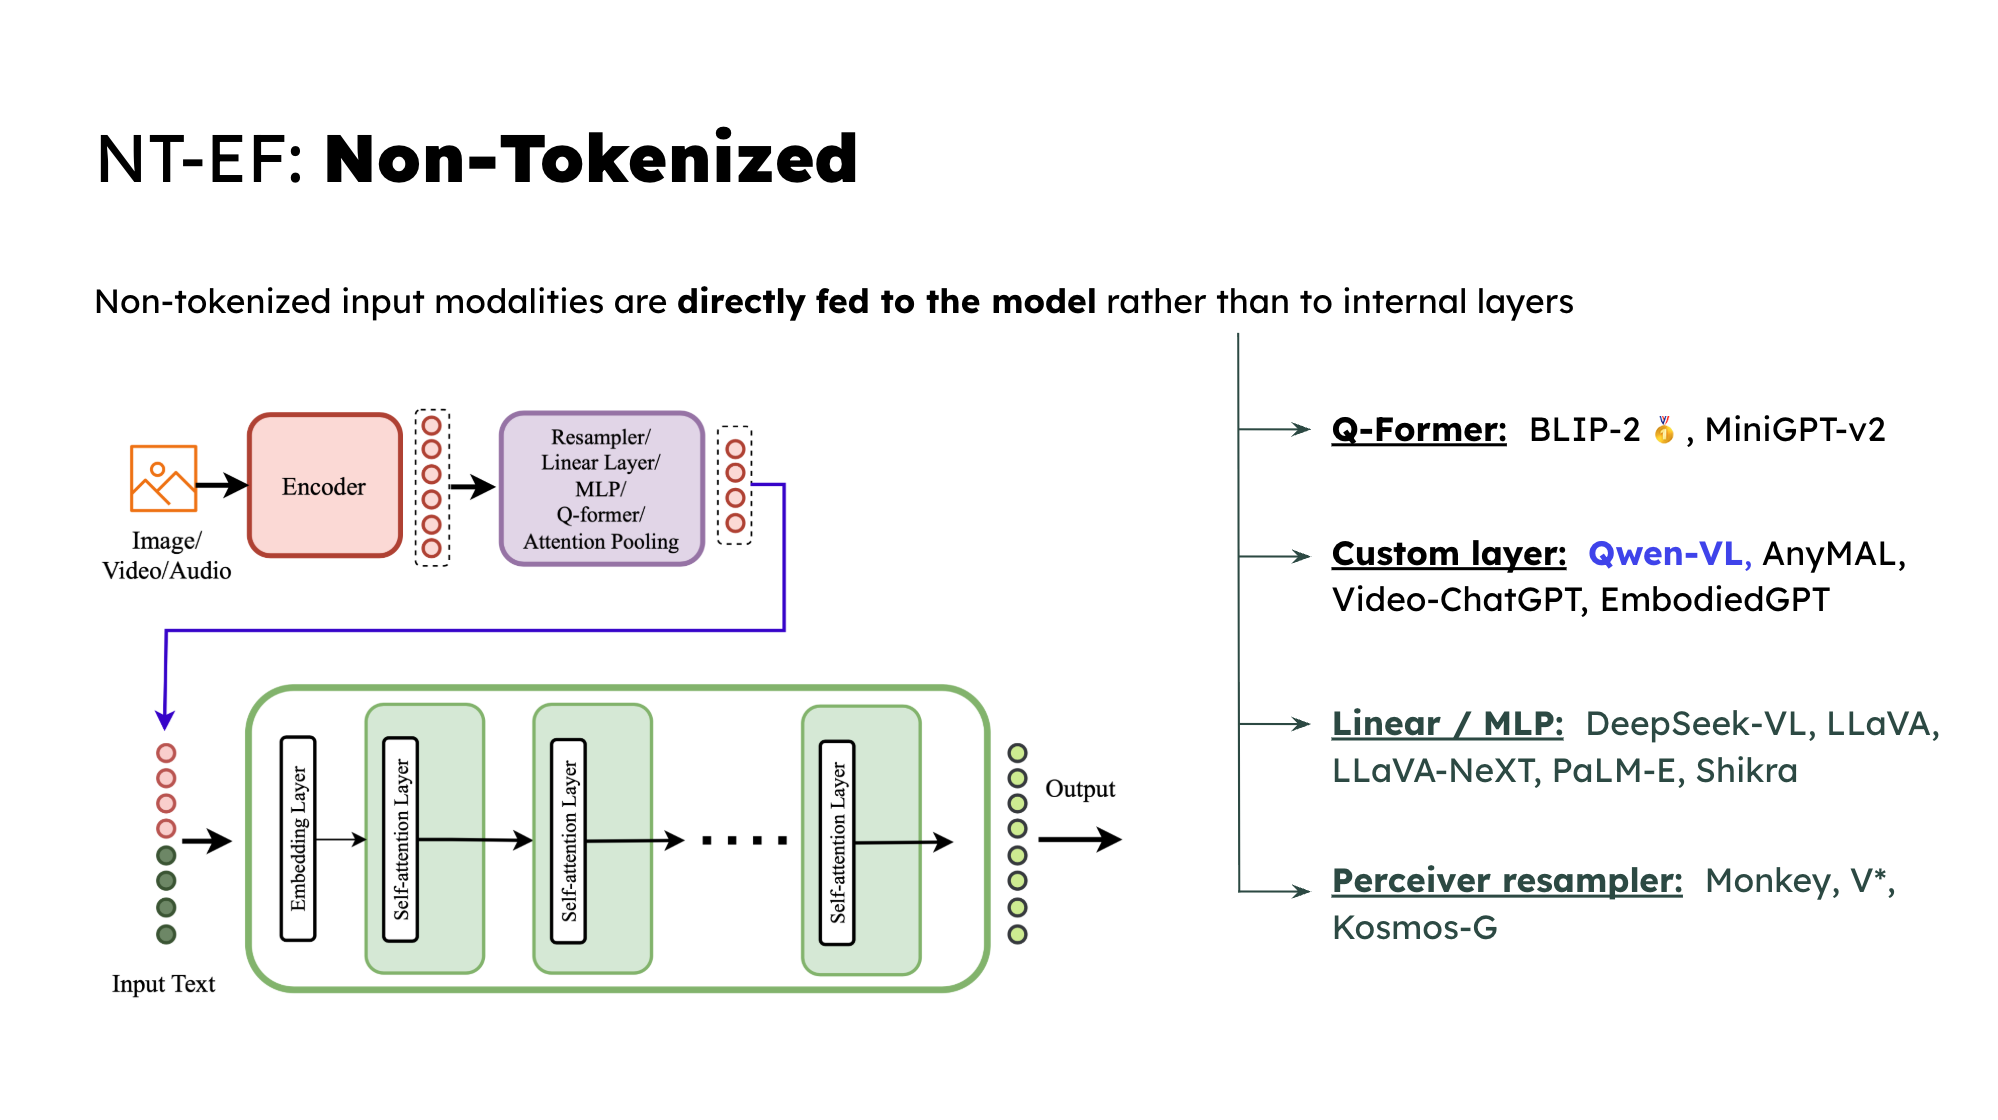

### 2.1 BLIP-2

BLIP-2 is the canonical NT-EF model. It connects a *frozen* ViT image encoder and a *frozen* OPT/T5 LLM through a small learnable module called the **Q-Former**:

* The Q-Former owns a fixed number of learnable **query tokens** (32 by default).
* Through cross-attention into the visual features, these queries extract a compact, language-aligned summary of the image.
* The output query embeddings are linearly projected into the LLM input space and prepended to the textual prompt as soft tokens; the LLM then generates the answer.

BLIP-2 is trained in two stages: (i) *vision–language representation learning* (image–text contrastive + matching + captioning losses) on the Q-Former alone, and (ii) *vision-to-language generative learning* with the LLM on top.

In this section we will use the public `Salesforce/blip2-opt-2.7b` checkpoint to do **zero-shot captioning, prompted captioning and zero-shot VQA**.

* Li et al., [*BLIP: Bootstrapping Language-Image Pre-training*](https://arxiv.org/abs/2201.12086)
* Li et al., [*BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models*](https://arxiv.org/abs/2301.12597)

In [ ]:
!pip install -q accelerate bitsandbytes

In [ ]:
import requests
from PIL import Image
from IPython.display import display

# Image of the Trevi Fountain (Rome) — a deliberately specific landmark
# that we will later use to probe BLIP-2's world knowledge.
url = 'https://cdn.blastness.biz/media/820/blog/thumbs/full/fontana-di-trevi-roma-copertina.jpg'
image = Image.open(requests.get(url, stream=True).raw).convert('RGB')
display(image.resize((596, 437)))

In [ ]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch

processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")

# Several ways to load the model — pick one based on the GPU memory you have:
#   * float32 (largest, ~30 GB):
#       model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b")
#   * float16 (~15 GB, the default we use here):
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16,
)
#   * int8 quantization via bitsandbytes (~8 GB, a bit slower):
#       model = Blip2ForConditionalGeneration.from_pretrained(
#           "Salesforce/blip2-opt-2.7b", device_map="auto", load_in_8bit=True,
#       )

In [ ]:
# The frozen visual tower (an EVA-CLIP ViT-g/14).
model.vision_model

In [ ]:
# The frozen language model (OPT-2.7B).
# YOUR CODE: use `model.qformer` to also inspect the Q-Former — the only
# component that is actually trained in BLIP-2 stage-2.
model.language_model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
model.to(device);

In [ ]:
# (a) Zero-shot captioning — no prompt at all.
inputs = processor(image, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print("zero-shot caption:", generated_text)

In [ ]:
# (b) Prompted captioning — bias the LLM with a textual prefix.
prompt = "this is a picture of"

inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print("prompted caption:", generated_text)

# YOUR CODE: try a few different prefixes — e.g. "an oil painting of",
# "a photo taken at night of", "in the style of Van Gogh, " — and see how
# the BLIP-2 caption changes.

In [ ]:
# (c) Zero-shot VQA — phrase the prompt in a "Question / Answer" template.
prompt = "Question: which city is this? Answer:"

inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=10)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print("VQA answer:", generated_text)

In [ ]:
# (d) Multi-turn "chain of thought" — concatenate previous (Q, A) turns into a
# single long prompt. BLIP-2 was *not* trained on dialog, but the frozen LLM
# inside it can still pick up the pattern from the prompt format.
context = [
    ("which city is this?", "rome"),
    ("how did you understand?", "it has specific statues"),
]
question = "where is the name Rome coming from?"
template = "Question: {} Answer: {}."

prompt = (
    " ".join(template.format(q, a) for q, a in context)
    + f" Question: {question} Answer:"
)
print(prompt)

In [ ]:
inputs = processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)

generated_ids = model.generate(**inputs, max_new_tokens=10)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print("chain-of-thought answer:", generated_text)

# YOUR CODE: pick a different image (e.g. of a famous painting / building / dish)
# and design a 2–3-turn QA prompt that tests BLIP-2's world knowledge about it.

## 3. Qwen-VL/Qwen2.5-Omni — a chat-tuned VLM

Qwen-VL takes the NT-EF idea further: it is built on top of a strong chat-tuned LLM (Qwen-7B-Chat) and is itself fine-tuned on multi-turn vision-grounded conversations. Compared with BLIP-2 it can:

* hold **multi-turn dialogues** about an image,
* read text in the image (OCR-like behavior),
* perform **visual grounding** — predict bounding boxes for entities mentioned in the conversation.

Architecturally Qwen-VL is again a frozen ViT (OpenCLIP ViT-bigG) connected to an LLM through a small cross-attention adapter; the difference from BLIP-2 is that the LLM is unfrozen during instruction tuning and the dataset includes box annotations.


Qwen2.5-Omni is an end-to-end multimodal model designed to perceive diverse modalities, including text, images, audio, and video, while simultaneously generating text and natural speech responses in a streaming manner. 

* Bai et al., [*Qwen-VL: A Versatile Vision-Language Model for Understanding, Localization, Text Reading, and Beyond*](https://arxiv.org/abs/2308.12966).
* [Hugging Face Qwen/Qwen2.5-Omni-3B](https://huggingface.co/Qwen/Qwen2.5-Omni-3B).

In [ ]:
! pip install accelerate==0.32.1 transformers==4.57.3 bitsandbytes==0.48.2 qwen-omni-utils[decode]==0.0.8
# maybe need to restart session

In [ ]:
# Environment variable (should be set before running Python, not inside script)
# export HF_HUB_DISABLE_XET=1

import torch
import transformers
from qwen_omni_utils import process_mm_info
from IPython.display import display, Audio, Image
from transformers import BitsAndBytesConfig  # added missing import

# Corrected model name (original had a typo)
MODEL_NAME = "Qwen/Qwen2.5-Omni-3B"  # or change to "Qwen/Qwen2.5-Omni-7B" with quantization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model with optional 4-bit quantization for the 7B version
model = transformers.Qwen2_5OmniForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
    low_cpu_mem_usage=True,
    quantization_config=None if MODEL_NAME.endswith("3B") else BitsAndBytesConfig(load_in_4bit=True)
)

# Load processor with reduced max_pixels to save GPU memory
processor = transformers.Qwen2_5OmniProcessor.from_pretrained(
    MODEL_NAME,
    max_pixels=240 * 240
)

# Correctly formatted system message
SYSTEM_MESSAGE = {
    "role": "system",
    "content": [
        {
            "type": "text",
            "text": "You are Qwen, a virtual human developed by the Qwen Team, Alibaba Group, capable of perceiving..."
        }
    ]
}

In [ ]:
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import requests


def load_image(url: str, save_path: str = "poster.jpeg"):
    """Download an image from `url` and persist it to `save_path` for Qwen-VL."""
    response = requests.get(url, stream=True)
    response.raise_for_status()
    content = response.content
    with open(save_path, "wb") as f:
        f.write(content)
    return Image.open(BytesIO(content))


def plot_image(image, title, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSD0qedAEEvk9S0-G_e3ur6BXTD_5k7UJ4Cog&s"

title = "Что изображено на картинке?"

image = load_image(url, save_path='img.jpeg')
plot_image(image, title)

In [ ]:
import numpy as np
from IPython.display import display, Audio, Image

# Correct conversation format (fixed missing closing bracket)
conversations = [
    SYSTEM_MESSAGE,
    {
        "role": "user",
        "content": [
            {"type": "image", "image": "img.jpeg"},  # image will be resized according to max_pixels
            {"type": "text", "text": title}
        ]
    }
]

# Apply chat template and process multimodal info
text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)

# Prepare inputs
inputs = processor(
    text=text,
    audio=audios,
    images=images,
    videos=videos,
    return_tensors="pt",
    padding=True,
    use_audio_in_video=True
).to(model.device)

# Generate text and audio
speaker = "Chelsie"  # or "Ethan" for male voice
text_ids, audio = model.generate(
    **inputs,
    speaker=speaker,
    use_audio_in_video=True,
    thinker_do_sample=False,
    talker_do_sample=True
)

# Decode generated text (remove prompt part)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:].cpu().numpy().astype(np.int32)
text_output = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)

# Display results
display(Image("img.jpeg"))
print(*text_output)

# Display audio (fixed rate argument name)
display(Audio(data=audio.reshape(-1).detach().cpu().numpy(), rate=24000))